# Ejercicio: Aprendizaje supervisado usando diferentes funciones de costo

En este ejercicio, profundizaremos en cómo pueden variar las funciones de costo:

* Qué tan bien parecen ajustarse los modelos a los datos  
* El tipo de relaciones que un modelo representa  

## Cargando los datos

Comencemos cargando los datos. Para hacer este ejercicio más sencillo, esta vez usaremos solo unos pocos puntos de datos.


In [1]:
import pandas
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/microsoft_custom_linear_regressor.py
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/seattleWeather_1948-2017.csv
from datetime import datetime

# Load a file that contains our weather data
dataset = pandas.read_csv('seattleWeather_1948-2017.csv', parse_dates=['date'])

# Convert the dates into numbers so we can use them in our models
# We make a year column that can contain fractions. For example,
# 1948.5 is halfway through the year 1948
dataset["year"] = [(d.year + d.timetuple().tm_yday / 365.25) for d in dataset.date]


# For the sake of this exercise, let's look at February 1 for the following years:
desired_dates = [
    datetime(1950,2,1),
    datetime(1960,2,1),
    datetime(1970,2,1),
    datetime(1980,2,1),
    datetime(1990,2,1),
    datetime(2000,2,1),
    datetime(2010,2,1),
    datetime(2017,2,1),
]

dataset = dataset[dataset.date.isin(desired_dates)].copy()

# Print the dataset
dataset


--2025-08-17 15:37:36--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/microsoft_custom_linear_regressor.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2167 (2.1K) [text/plain]
Saving to: ‘microsoft_custom_linear_regressor.py’

microsoft_custom_li 100%[===================>]   2.12K  --.-KB/s    in 0s      

2025-08-17 15:37:36 (39.4 MB/s) - ‘microsoft_custom_linear_regressor.py’ saved [2167/2167]

--2025-08-17 15:37:38--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/seattleWeather_1948-2017.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com 

,date,amount_of_precipitation,max_temperature,min_temperature,rain,year
762,1950-02-01,0.00,27,1,False,1950.087611
4414,1960-02-01,0.15,52,44,True,1960.087611
8067,1970-02-01,0.00,50,42,False,1970.087611
11719,1980-02-01,0.37,54,36,True,1980.087611
15372,1990-02-01,0.08,45,37,True,1990.087611
19024,2000-02-01,1.34,49,41,True,2000.087611
22677,2010-02-01,0.08,49,40,True,2010.087611
25234,2017-02-01,0.00,43,29,False,2017.087611


## Comparando dos funciones de costo

Comparemos dos funciones de costo comunes: la _suma de las diferencias al cuadrado_ (SSD) y la _suma de las diferencias absolutas_ (SAD). Ambas calculan la diferencia entre cada valor predicho y el valor esperado. La distinción es simplemente:

* SSD eleva al cuadrado esa diferencia y suma el resultado.  
* SAD convierte las diferencias en valores absolutos y luego suma esos resultados.  

Para ver estas funciones de costo en acción, primero necesitamos implementarlas:


In [2]:
import numpy

def sum_of_square_differences(estimate, actual):
    # Note that with NumPy, to square each value we use **
    return numpy.sum((estimate - actual)**2)

def sum_of_absolute_differences(estimate, actual):
    return numpy.sum(numpy.abs(estimate - actual))

Son muy similares. ¿Cómo se comportan? Probemos con algunas estimaciones ficticias del modelo.  

Supongamos que las respuestas correctas son `1` y `3`, pero el modelo estima `2` y `2`:  


In [3]:
actual_label = numpy.array([1, 3])
model_estimate = numpy.array([2, 2])

print("SSD:", sum_of_square_differences(model_estimate, actual_label))
print("SAD:", sum_of_absolute_differences(model_estimate, actual_label))

SSD: 2
SAD: 2


Tenemos un error de `1` para cada estimación, y ambos métodos han devuelto el mismo error.

¿Qué pasa si distribuimos estos errores de forma diferente? Imaginemos que estimamos el primer valor perfectamente, pero nos equivocamos en `2` en el segundo valor:

In [4]:
actual_label = numpy.array([1, 3])
model_estimate = numpy.array([1, 1])

print("SSD:", sum_of_square_differences(model_estimate, actual_label))
print("SAD:", sum_of_absolute_differences(model_estimate, actual_label))

SSD: 4
SAD: 2


SAD ha calculado el mismo costo que antes, porque el error promedio sigue siendo el mismo (`1 + 1 = 0 + 2`). Según SAD, el primer y el segundo conjunto de estimaciones fueron igual de buenos. 

En cambio, SSD ha dado un costo mayor (peor) para el segundo conjunto de estimaciones ($1^2 + 1^2 < 0^2 + 2^2$). Cuando usamos SSD, fomentamos que los modelos sean tanto precisos como consistentes en su precisión.

## Diferencias en acción

Comparemos cómo nuestras dos funciones de costo afectan el ajuste del modelo.

Primero, ajusta un modelo usando la función de costo SSD:

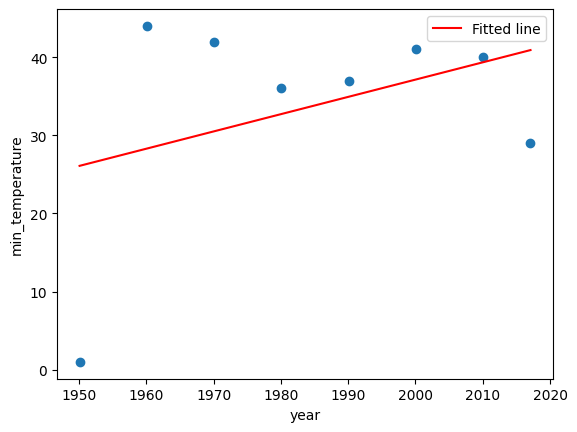

In [5]:
from microsoft_custom_linear_regressor import MicrosoftCustomLinearRegressor
import matplotlib.pyplot as plt

# Create and fit the model
# We use a custom object that we've hidden from this notebook, because
# you don't need to understand its details. This fits a linear model
# by using a provided cost function

# Fit a model by using sum of square differences
model = MicrosoftCustomLinearRegressor().fit(X = dataset.year, 
                                             y = dataset.min_temperature, 
                                             cost_function = sum_of_square_differences)

# Graph the model
plt.scatter(dataset["year"], dataset["min_temperature"])
plt.plot(dataset["year"], model.predict(dataset["year"]), 'r', label='Fitted line')

                                                 
# add labels and legend
plt.xlabel("year")
plt.ylabel("min_temperature")
plt.legend()

Nuestro método SSD normalmente funciona bien, pero aquí hizo un mal trabajo. La línea está bastante alejada de los valores de muchos años. ¿Por qué? Observa que el punto de datos en la parte inferior izquierda no parece seguir la tendencia de los demás puntos. El invierno de 1950 fue muy frío en Seattle, y este punto de datos está influyendo fuertemente en nuestro modelo final (la línea roja). ¿Qué pasa si cambiamos la función de costo?

### Suma de diferencias absolutas

Repitamos lo que acabamos de hacer, pero usando SAD.


/anaconda/envs/azureml_py38/lib/python3.8/site-packages/scipy/optimize/optimize.py:1166: RuntimeWarning: divide by zero encountered in double_scalars
  rhok = 1.0 / (np.dot(yk, sk))


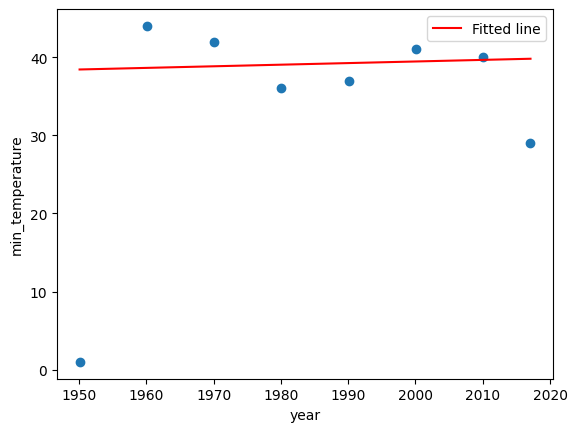

In [6]:
# Fit a model with SAD
# Fit a model by using sum of absolute differences
model = MicrosoftCustomLinearRegressor().fit(X = dataset.year, 
                                             y = dataset.min_temperature, 
                                             cost_function = sum_of_absolute_differences)

# Graph the model
plt.scatter(dataset["year"], dataset["min_temperature"])
plt.plot(dataset["year"], model.predict(dataset["year"]), 'r', label='Fitted line')

                                                 
# add labels and legend
plt.xlabel("year")
plt.ylabel("min_temperature")
plt.legend()


Es evidente que esta línea pasa por la mayoría de los puntos mucho mejor que antes, a costa de casi ignorar la medición tomada en 1950.  

En nuestro escenario agrícola, nos interesa cómo están cambiando las temperaturas promedio con el tiempo. No tenemos mucho interés específico en 1950, por lo que, para nosotros, este es un mejor resultado. En otras situaciones, por supuesto, podríamos considerar que este resultado es peor.  

## Resumen

En este ejercicio, aprendiste cómo cambiar la función de costo utilizada durante el ajuste puede dar lugar a diferentes resultados finales.  

También aprendiste que este comportamiento ocurre porque estas funciones de costo describen la manera "óptima" de ajustar un modelo; aunque, desde el punto de vista de un analista de datos, puede haber desventajas sin importar qué función de costo se elija.  


No hay un **método universalmente mejor**; depende del problema y de los datos. Te resumo las diferencias:


## 🔹 SSD (Sum of Squared Differences)

* **Cómo funciona:** eleva al cuadrado cada error antes de sumarlos.
* **Consecuencia:** los errores grandes pesan mucho más (se amplifican).
* **Ventajas:**

  * Obliga al modelo a ser más preciso de manera consistente.
  * Es el estándar en estadística y machine learning porque conduce a soluciones matemáticamente estables (derivadas suaves, útil para optimización).
* **Desventajas:**

  * Muy sensible a *outliers* (valores atípicos). Un solo dato raro puede desviar la línea, como pasó con el invierno de 1950 en el ejercicio.


## 🔹 SAD (Sum of Absolute Differences)

* **Cómo funciona:** toma el valor absoluto de los errores antes de sumarlos.
* **Consecuencia:** cada error cuenta de manera proporcional, sin importar si es muy grande o pequeño.
* **Ventajas:**

  * Más robusto frente a *outliers*.
  * El modelo se ajusta al “patrón general” de los datos.
* **Desventajas:**

  * Matemáticamente menos conveniente para optimización (no es derivable en cero).
  * Puede ser menos eficiente en contextos donde la mayoría de los datos son muy consistentes.


## ✅ ¿Cuál usar?

* Si tus datos **no tienen valores atípicos importantes** y necesitas precisión matemática → **SSD** suele ser la mejor elección.
* Si tus datos **tienen outliers** o te interesa el **comportamiento promedio general** → **SAD** puede dar un modelo más realista.

En tu escenario agrícola (temperaturas históricas), **SAD fue mejor** porque el outlier de 1950 distorsionaba demasiado el modelo con SSD.


### En pocas palabras:

* **SSD = más preciso pero sensible a outliers.**
* **SAD = más robusto pero menos matemáticamente “suave”.**

¿Quieres que te arme una **tabla comparativa resumida tipo chuleta** para que lo tengas siempre a mano?

Perfecto 🙌 Aquí tienes una tabla comparativa clara y resumida entre **SSD** y **SAD**:

| Característica              | **SSD (Sum of Squared Differences)**                                           | **SAD (Sum of Absolute Differences)**                                |
| --------------------------- | ------------------------------------------------------------------------------ | -------------------------------------------------------------------- |
| **Definición**              | Suma de los errores elevados al cuadrado                                       | Suma de los valores absolutos de los errores                         |
| **Sensibilidad a outliers** | Muy sensible (un valor extremo puede desviar mucho el modelo)                  | Robusto (los outliers afectan menos)                                 |
| **Interpretación**          | Penaliza fuertemente errores grandes                                           | Trata todos los errores de manera proporcional                       |
| **Usos comunes**            | Regresión lineal clásica, modelos estadísticos, machine learning estándar      | Modelos robustos, datos con ruido o valores atípicos                 |
| **Ventaja principal**       | Precisión y estabilidad matemática (derivadas suaves → optimización más fácil) | Más representativo del “patrón general” en datos reales con outliers |
| **Desventaja principal**    | Puede dar modelos distorsionados por pocos valores extremos                    | Menos conveniente para optimización (no derivable en 0)              |


### Resumen rápido:

* Usa **SSD** si tus datos son limpios y quieres precisión matemática.
* Usa **SAD** si tus datos tienen *outliers* o te importa más la tendencia general que los valores extremos.


